# vi.ve — Style Evolution Review: How *Riding Trap* Got Established

Eight trials from 0% keep rate to an **established style generator** (2026-07-13). This notebook is the analytical record of that arc: what each trial changed, what the verdicts said, and the one big failure that taught the most.

| Trial | Change | Result |
|---|---|---|
| 01 | bar-collage everything | 0/24 — melodies channel-surf |
| 02 | grammar melody engine | 11/24 (46%) |
| 03 | anchor lock, one-vocab melody, bass register shape | 17/24 (71%) |
| 04 | melody register clamp + overlap fix | 19/24 (79%) |
| 05 | keep/ehh/cream tiers; the v04 dice experiment | 24/24 keep, 18 cream — dice variance proven |
| 06 | bass lane + root landing + candidate gate | harsher standards: bass exposed (1/8) |
| 07 | 808 frame + pitch-folds | **all basslines fail** → post-mortem |
| 08 | remove contaminated source from the pool | ✅ **riding trap established** |

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*SQLAlchemy.*")
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
KIND_COLORS = {"melody": "#2a78d6", "bassline": "#1baf7a", "drums": "#eda100"}
BLUE, RED = "#2a78d6", "#e34948"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "grid.color": GRID,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

DATA = Path("../data")
conn = psycopg2.connect(dbname="vive", port=5431)
q = lambda sql: pd.read_sql(sql, conn)
print("connected")

/Users/trell/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


connected


## 1 · The keep-rate arc

Per component, per graded trial. (Trial 7 was rejected wholesale by ear without grading — plotted as zero for basslines, ungraded elsewhere; trial 8 was declared the win that established the style.)

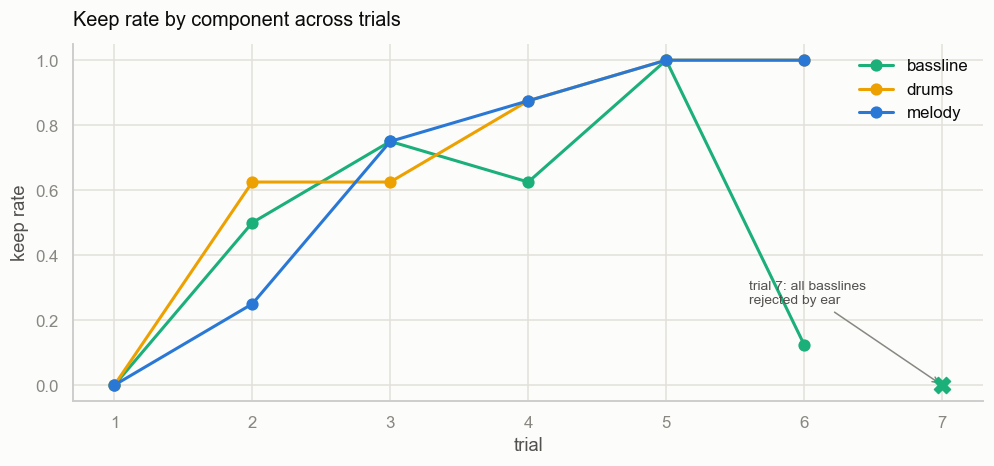

In [2]:
kr = q("""SELECT trial, file_kind,
                 count(*) FILTER (WHERE keep)::float / count(*) AS keep_rate
          FROM trial_results WHERE file_kind <> 'pack'
          GROUP BY trial, file_kind ORDER BY trial""")

fig, ax = plt.subplots(figsize=(9.2, 4.4))
for kind, g in kr.groupby("file_kind"):
    ax.plot(g.trial, g.keep_rate, "o-", color=KIND_COLORS[kind], lw=2, ms=7, label=kind)
ax.scatter([7], [0], color=KIND_COLORS["bassline"], marker="X", s=110, zorder=5)
ax.annotate("trial 7: all basslines\nrejected by ear", xy=(7, 0), xytext=(5.6, 0.25),
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="->", color=MUTED))
ax.set_title("Keep rate by component across trials", loc="left", fontsize=13, pad=12)
ax.set_xlabel("trial"); ax.set_ylabel("keep rate")
ax.set_ylim(-0.05, 1.05); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Melodies and drums climbed steadily once each got its dedicated engine. Basslines climbed, then **collapsed under the evolved standards** (trials 6–7) — not because they got worse, but because the grading got honest about a contamination that was there all along.

## 2 · The post-mortem finding — one source poisoned the well

Every flagged/failed bassline traced to bars from **out there's verse bassline** (the retired +8/octave/octave/+5 counter-melody structure). Share of bass bars drawn from that source, by trial — including the feedback loop that made it *grow* (flagged recipes kept getting re-rolled as "fix checks," and flags correlated with out-there weight):

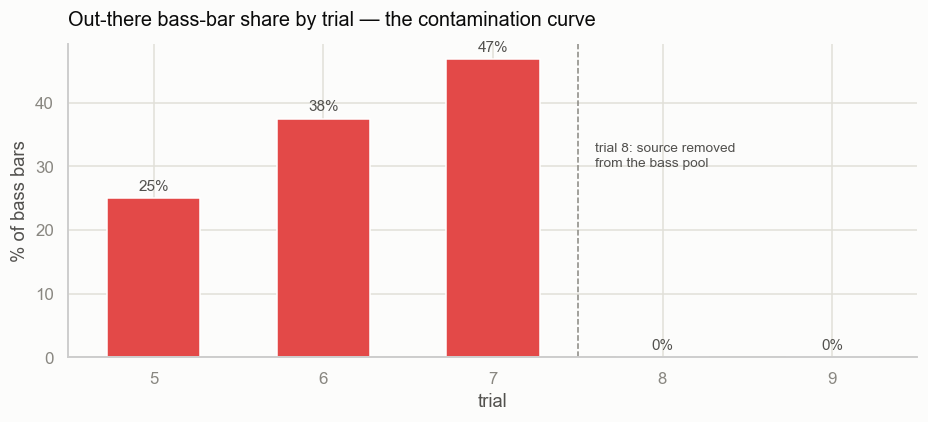

In [3]:
shares = {}
for t in (5, 6, 7, 8, 9):
    p = DATA / f"generation_run_trial_{t:02}.json"
    if not p.exists():
        continue
    run = json.loads(p.read_text())
    bars = [s for c in run["combos"] for s in c["bar_sources"].get("kick+bass (locked)", [])]
    shares[t] = 100 * sum(1 for s in bars if s == "out there") / len(bars)

fig, ax = plt.subplots(figsize=(8.6, 4))
trials = list(shares)
colors = [RED if v > 0 else "#008300" for v in shares.values()]
bars = ax.bar([str(t) for t in trials], list(shares.values()), color=colors, width=0.55)
ax.bar_label(bars, fmt="%.0f%%", fontsize=10, color=INK2, padding=3)
ax.axvline(2.5, color=MUTED, lw=1, ls="--")
ax.annotate("trial 8: source removed\nfrom the bass pool", xy=(2.6, 30), fontsize=9, color=INK2)
ax.set_title("Out-there bass-bar share by trial — the contamination curve",
             loc="left", fontsize=13, pad=12)
ax.set_xlabel("trial"); ax.set_ylabel("% of bass bars")
plt.tight_layout(); plt.show()

The math that made it inevitable: with per-bar weighted dice, P(a source appears in a 4-bar pattern) = `1-(1-w)⁴` — 87% at weight 0.4. **Down-weighting a disliked structure can't remove it; only curation can.** That's the biggest single lesson of the project so far.

## 3 · What the diagnostic flags caught (manifest v2, trials 5–6)

In [4]:
fl = q("""SELECT trial, file_kind,
                 count(*) FILTER (WHERE wrong_lane) AS wrong_lane,
                 count(*) FILTER (WHERE bad_landing) AS bad_landing,
                 count(*) FILTER (WHERE too_random) AS too_random,
                 count(*) FILTER (WHERE too_repetitive) AS too_repetitive
          FROM trial_results WHERE trial IN (5, 6) AND file_kind <> 'pack'
          GROUP BY trial, file_kind ORDER BY trial, file_kind""")
fl

,trial,file_kind,wrong_lane,bad_landing,too_random,too_repetitive
0,5,bassline,4,4,2,2
1,5,drums,0,0,0,1
2,5,melody,0,0,0,0
3,6,bassline,7,6,1,3
4,6,drums,0,0,0,0
5,6,melody,0,0,0,0


Wrong-lane and bad-landing concentrated entirely on basslines — the flags pointed at the contamination a full trial before the post-mortem proved it. **The expanded manifest paid for itself immediately.**

## 4 · The styles registry — where cream formulas live

In [5]:
q("""SELECT name, created, recipe->>'status' AS status,
            recipe->>'exemplar_combo' AS exemplar, verdict
     FROM styles ORDER BY id""")

,name,created,status,exemplar,verdict
0,riding trap,2026-07-13,ESTABLISHED,None,ESTABLISHED 2026-07-13 after 8 trials (keep ar...
1,cream-t5-v01,2026-07-15,None,v01,all 3 files cream
2,cream-t5-v03,2026-07-15,None,v03,all 3 files cream
3,cream-t5-v04,2026-07-15,None,v04,all 3 files cream
4,cream-t6-v05,2026-07-15,None,v05,all 3 files cream


## 5 · Lessons the next style inherits

1. **Score/feel split works** — pattern engines and feel rules are independently tunable.
2. **Weights are probabilities of inheritance, not mix percentages** — and dice variance is real, so a candidate gate (best-of-N against a rubric) belongs in every generator.
3. **Curation beats weighting** — a rejected structure must leave the pool; `1-(1-w)⁴` guarantees it survives any down-weighting.
4. **Tiered grading (keep/ehh/cream) + diagnostic flags** turn taste into knob-turns; single y/n is too noisy at the boundary.
5. **Melodies need one vocabulary**; basslines need a lane, a bounce, and a landing.
6. **More hand-played source packs = more variety** — the engine's ceiling is the dataset. Next packs feed directly into new styles.

*Next up the roadmap: the `vive` package (seeded as `scripts/vive_engine.py`), ask-for-what-you-want generation, then the assistant bot; waveform analysis for mixing and audio-to-MIDI beyond that.*